# Notebook 2 — Nonlinear mass-spring-damper: EKF vs UKF covariance learning

**Goal**: compare the Extended Kalman Filter (EKF) and Unscented Kalman Filter (UKF) on a
nonlinear mechanical system — a **Duffing oscillator** (mass-spring with cubic stiffness term).

$$\ddot{x} = -k x - k_3 x^3 - c\dot{x}$$

Discretised by Euler with `dt = 0.05 s`:

$$f(x_k) = \begin{pmatrix}x + v\,\Delta t \\ v + (-k x - k_3 x^3 - c v)\,\Delta t\end{pmatrix}, \quad h(x) = x_1$$

**Parameters**: `k = 1.0`, `k₃ = 0.5`, `c = 0.2`.  
**State**: `[position, velocity]` — only position is observed.

The cubic term makes the EKF Jacobian non-trivial and the UKF sigma-point propagation
meaningfully different from the linear KF case.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor
from torch.utils.data import DataLoader

from automatic_kalman.covariance import CholeskyCovariance
from automatic_kalman.data.generators import NonlinearGenerator, TrajectoryDataset
from automatic_kalman.filters.ekf import ExtendedKalmanFilter
from automatic_kalman.filters.ukf import UnscentedKalmanFilter
from automatic_kalman.losses import nis_consistency
from automatic_kalman.train import train

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (10, 4)})

## 1  System definition

Both `f` and `h` are plain PyTorch callables — single-sample, no explicit batching.  
The filters handle batching internally via `torch.func.vmap`.

In [2]:
DT   = 0.05
K    = 1.0
K3   = 0.5
C    = 0.2
dim_x, dim_z = 2, 1


def f(x: Tensor, u: Tensor | None) -> Tensor:
    """Duffing oscillator — single state vector (dim_x,)."""
    pos, vel = x[0], x[1]
    return torch.stack([
        pos + vel * DT,
        vel + (-K * pos - K3 * pos**3 - C * vel) * DT,
    ])


def h(x: Tensor) -> Tensor:
    """Position-only observation — single state vector (dim_x,)."""
    return x[:1]


# True noise covariances
Q_true = torch.diag(torch.tensor([1e-2, 1e-2], dtype=torch.float64))
R_true = torch.tensor([[0.1]], dtype=torch.float64)

# Target starts with small displacement (mildly nonlinear regime)
x0_state = torch.tensor([0.3, 0.0], dtype=torch.float64)

print(f"Duffing parameters: k={K}, k3={K3}, c={C}, dt={DT}")
print(f"Q_true = diag{Q_true.diagonal().tolist()}")
print(f"R_true = {R_true.item():.3f}")

Duffing parameters: k=1.0, k3=0.5, c=0.2, dt=0.05
Q_true = diag[0.01, 0.01]
R_true = 0.100


## 2  Data generation

The `NonlinearGenerator` handles batched simulation via `torch.func.vmap` internally.
We use **200 trajectories × 60 steps** for training and **300 × 100** for evaluation.

In [3]:
torch.manual_seed(10)
gen = NonlinearGenerator(f=f, h=h, Q_true=Q_true, R_true=R_true, x0=x0_state)

batch_train = gen(B=200, T=60)
batch_eval  = gen(B=300, T=100)

dataset = TrajectoryDataset(batch_train)
loader  = DataLoader(dataset, batch_size=20, shuffle=True)

print(f"Train measurements: {batch_train.measurements.shape}")
print(f"Eval  measurements: {batch_eval.measurements.shape}")

Train measurements: torch.Size([200, 60, 1])
Eval  measurements: torch.Size([300, 100, 1])


## 3  Covariance initialisation helpers

In [4]:
def softplus_inv(x: Tensor) -> Tensor:
    return torch.log(torch.expm1(x))


def init_cov_at_scale(
    cov: CholeskyCovariance,
    L_true: Tensor,
    scale: float,
) -> None:
    with torch.no_grad():
        target = scale * L_true
        L_raw = target.clone()
        L_raw.diagonal().copy_(softplus_inv(target.diagonal()))
        cov._L_raw.data.copy_(L_raw)


L_Q_true = torch.linalg.cholesky(Q_true)
L_R_true = torch.linalg.cholesky(R_true)
INIT_SCALE = math.sqrt(10.0)

## 4  Train EKF — NIS path

The EKF linearises `f` and `h` at the current state via `torch.func.jacrev`.  
Gradients flow back through the Jacobian computation automatically.

In [5]:
torch.manual_seed(20)
ekf = ExtendedKalmanFilter(f=f, h=h, dim_x=dim_x, dim_z=dim_z)

cov_Q_ekf = CholeskyCovariance(dim=dim_x)
cov_R_ekf = CholeskyCovariance(dim=dim_z)
init_cov_at_scale(cov_Q_ekf, L_Q_true, INIT_SCALE)
init_cov_at_scale(cov_R_ekf, L_R_true, INIT_SCALE)

x0_f = torch.zeros(dim_x, dtype=torch.float64)
P0_f = torch.eye(dim_x, dtype=torch.float64)

losses_ekf = train(
    filter=ekf,
    cov_Q=cov_Q_ekf,
    cov_R=cov_R_ekf,
    loss_fn=nis_consistency,
    loader=loader,
    x0=x0_f,
    P0=P0_f,
    epochs=150,
    lr=0.03,
)

print(f"EKF NIS loss: {losses_ekf[0]:.4f} → {losses_ekf[-1]:.4f}")

EKF NIS loss: 0.9470 → -2.0867


## 5  Train UKF — NIS path

The UKF propagates 2n+1 sigma points through the nonlinear `f` and `h` — no Jacobians
required.  We use `alpha=0.3` for numerically well-conditioned sigma-point weights
(the default `alpha=1e-3` gives extreme weights that are harder to optimise through).

Both filters see the **same training data** (same seed, same trajectories).

In [6]:
torch.manual_seed(20)  # same seed as EKF for a fair comparison
ukf = UnscentedKalmanFilter(f=f, h=h, dim_x=dim_x, dim_z=dim_z, alpha=0.3)

# Re-generate same data (same seed)
torch.manual_seed(10)
gen2 = NonlinearGenerator(f=f, h=h, Q_true=Q_true, R_true=R_true, x0=x0_state)
batch_train2 = gen2(B=200, T=60)
dataset2 = TrajectoryDataset(batch_train2)
loader2  = DataLoader(dataset2, batch_size=20, shuffle=True)

torch.manual_seed(20)
cov_Q_ukf = CholeskyCovariance(dim=dim_x)
cov_R_ukf = CholeskyCovariance(dim=dim_z)
init_cov_at_scale(cov_Q_ukf, L_Q_true, INIT_SCALE)
init_cov_at_scale(cov_R_ukf, L_R_true, INIT_SCALE)

losses_ukf = train(
    filter=ukf,
    cov_Q=cov_Q_ukf,
    cov_R=cov_R_ukf,
    loss_fn=nis_consistency,
    loader=loader2,
    x0=x0_f,
    P0=P0_f,
    epochs=150,
    lr=0.03,
)

print(f"UKF NIS loss: {losses_ukf[0]:.4f} → {losses_ukf[-1]:.4f}")

UKF NIS loss: 0.9468 → -2.0870


## 6  Loss curves — EKF vs UKF

Both should converge to near-zero.  The UKF may converge faster or to a lower final loss
because it captures higher-order moments that the EKF's first-order linearisation misses.

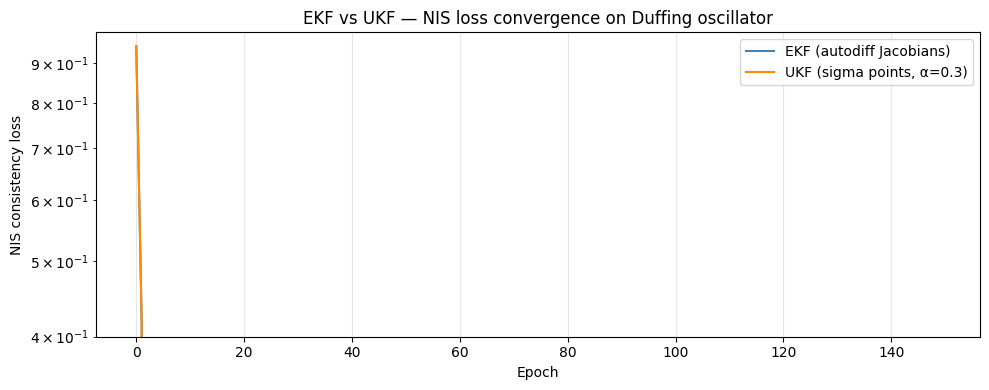

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses_ekf, color="steelblue",  label="EKF (autodiff Jacobians)")
ax.plot(losses_ukf, color="darkorange", label="UKF (sigma points, α=0.3)")
ax.set_xlabel("Epoch")
ax.set_ylabel("NIS consistency loss")
ax.set_title("EKF vs UKF — NIS loss convergence on Duffing oscillator")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7  Learned Q and R — EKF vs UKF vs ground truth

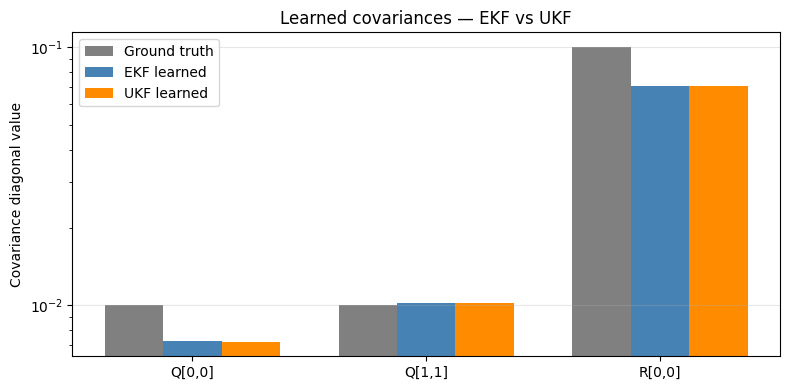

Ground truth: Q diag = ['1.000e-02', '1.000e-02']  R = 1.000e-01
EKF learned:  Q diag = ['7.312e-03', '1.023e-02']  R = 7.072e-02
UKF learned:  Q diag = ['7.248e-03', '1.025e-02']  R = 7.079e-02


In [8]:
with torch.no_grad():
    Q_ekf = cov_Q_ekf.matrix().detach()
    R_ekf = cov_R_ekf.matrix().detach()
    Q_ukf = cov_Q_ukf.matrix().detach()
    R_ukf = cov_R_ukf.matrix().detach()

labels  = ["Q[0,0]", "Q[1,1]", "R[0,0]"]
truth_v = [Q_true[0, 0].item(), Q_true[1, 1].item(), R_true[0, 0].item()]
ekf_v   = [Q_ekf[0, 0].item(),  Q_ekf[1, 1].item(),  R_ekf[0, 0].item()]
ukf_v   = [Q_ukf[0, 0].item(),  Q_ukf[1, 1].item(),  R_ukf[0, 0].item()]

x_pos = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos - width, truth_v, width, label="Ground truth",  color="gray")
ax.bar(x_pos,         ekf_v,   width, label="EKF learned",   color="steelblue")
ax.bar(x_pos + width, ukf_v,   width, label="UKF learned",   color="darkorange")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_yscale("log")
ax.set_ylabel("Covariance diagonal value")
ax.set_title("Learned covariances — EKF vs UKF")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Ground truth: Q diag =", [f"{v:.3e}" for v in truth_v[:2]], " R =", f"{truth_v[2]:.3e}")
print("EKF learned:  Q diag =", [f"{v:.3e}" for v in ekf_v[:2]],   " R =", f"{ekf_v[2]:.3e}")
print("UKF learned:  Q diag =", [f"{v:.3e}" for v in ukf_v[:2]],   " R =", f"{ukf_v[2]:.3e}")

## 8  NIS on held-out data — EKF vs UKF

Under correct tuning, `E[NIS] = dim_z = 1`.  We run both filters on the 300-trajectory
evaluation set and plot per-step mean NIS with the chi-squared confidence band.

The UKF tends to give better NIS consistency for the Duffing system because it captures
the non-Gaussian deformation of the predictive distribution that linearisation misses.

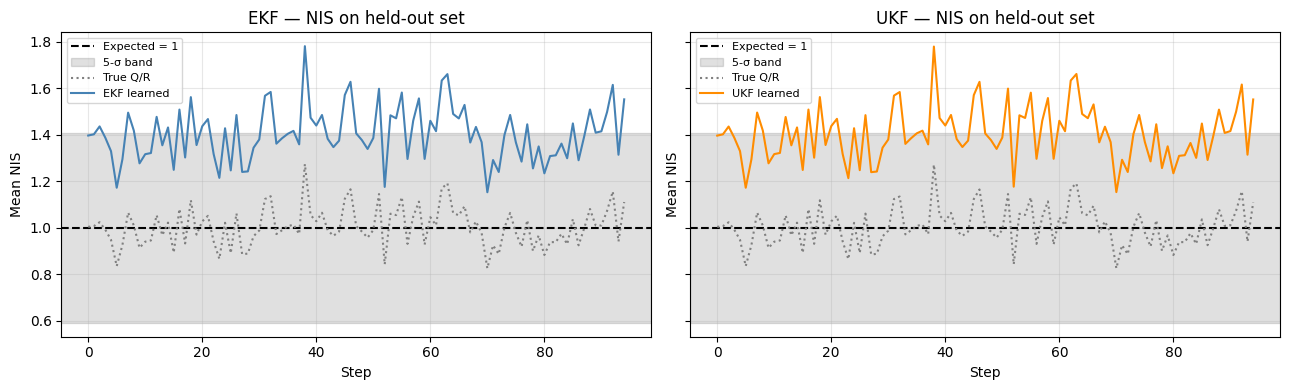

In [9]:
def run_nis_steps(
    filt,
    measurements: Tensor,
    Q: Tensor,
    R: Tensor,
    skip: int = 5,
) -> list[float]:
    """Return mean NIS at each time step (after warm-up)."""
    B, T, _ = measurements.shape
    x = torch.zeros(B, dim_x, dtype=torch.float64)
    P = torch.eye(dim_x, dtype=torch.float64).unsqueeze(0).expand(B, -1, -1).clone()
    nis_steps = []
    with torch.no_grad():
        for t in range(T):
            x, P = filt.predict(x, P, Q)
            x, P, y, S = filt.update(x, P, measurements[:, t, :], R)
            if t >= skip:
                L_S = torch.linalg.cholesky(S)
                nis = (y * torch.cholesky_solve(y.unsqueeze(-1), L_S).squeeze(-1)).sum(-1)
                nis_steps.append(nis.mean().item())
    return nis_steps


z_eval = batch_eval.measurements
nis_ekf  = run_nis_steps(ekf, z_eval, Q_ekf, R_ekf)
nis_ukf  = run_nis_steps(ukf, z_eval, Q_ukf, R_ukf)
nis_true_ekf = run_nis_steps(ekf, z_eval, Q_true, R_true)
nis_true_ukf = run_nis_steps(ukf, z_eval, Q_true, R_true)

se5 = 5.0 * math.sqrt(2.0 * dim_z / len(z_eval))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, nis_learned, nis_gt, title, color in [
    (axes[0], nis_ekf, nis_true_ekf, "EKF", "steelblue"),
    (axes[1], nis_ukf, nis_true_ukf, "UKF", "darkorange"),
]:
    steps = list(range(len(nis_gt)))
    ax.axhline(dim_z, color="black",  linestyle="--", label=f"Expected = {dim_z}")
    ax.axhspan(dim_z - se5, dim_z + se5, alpha=0.12, color="black", label="5-σ band")
    ax.plot(steps, nis_gt,      color="gray",  linestyle=":",  label="True Q/R")
    ax.plot(steps, nis_learned, color=color,                   label=f"{title} learned")
    ax.set_xlabel("Step")
    ax.set_ylabel("Mean NIS")
    ax.set_title(f"{title} — NIS on held-out set")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9  State estimation: position and velocity

We run both filters on a single held-out trajectory and visualise:
- **position** with 3-σ uncertainty bands,
- **velocity** with 3-σ uncertainty bands,
- the true trajectory and noisy position measurements for reference.

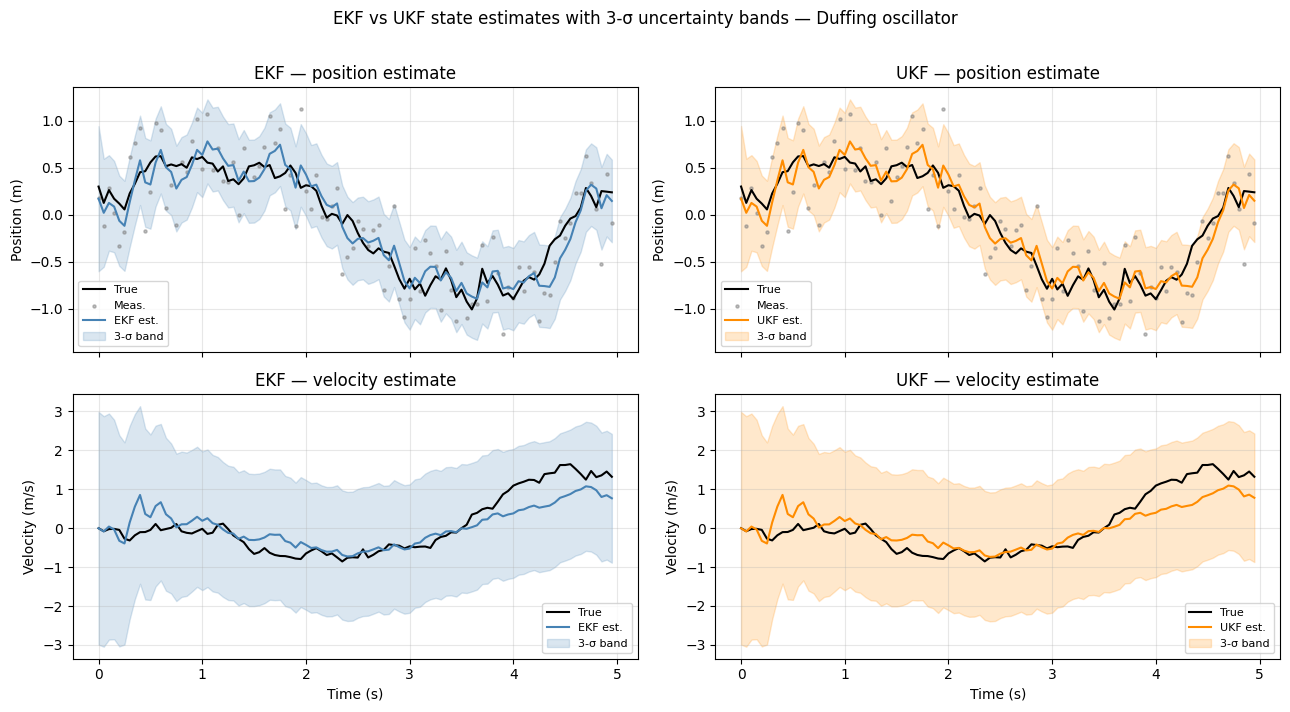

In [10]:
traj_idx = 0
z_one   = batch_eval.measurements[traj_idx]   # (T, 1)
x_true  = batch_eval.states[traj_idx]         # (T, 2)
T_eval  = z_one.shape[0]
time    = np.arange(T_eval) * DT


def run_single(filt, Q: Tensor, R: Tensor):
    """Run filter on the single trajectory, return (T, 2) means and (T, 2) stds."""
    x = torch.zeros(1, dim_x, dtype=torch.float64)
    P = torch.eye(dim_x, dtype=torch.float64).unsqueeze(0).clone()
    xs, stds = [], []
    with torch.no_grad():
        for t in range(T_eval):
            x, P = filt.predict(x, P, Q)
            x, P, _, _ = filt.update(x, P, z_one[t:t+1], R)
            xs.append(x[0].numpy().copy())
            stds.append(np.sqrt(np.diag(P[0].numpy())))
    return np.array(xs), np.array(stds)


xs_ekf, std_ekf = run_single(ekf, Q_ekf, R_ekf)
xs_ukf, std_ukf = run_single(ukf, Q_ukf, R_ukf)
x_true_np = x_true.numpy()

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

for col, (xs, stds, label, color) in enumerate([
    (xs_ekf, std_ekf, "EKF", "steelblue"),
    (xs_ukf, std_ukf, "UKF", "darkorange"),
]):
    for row, (state_idx, state_name) in enumerate([(0, "Position (m)"), (1, "Velocity (m/s)")]):
        ax = axes[row, col]
        ax.plot(time, x_true_np[:, state_idx], "k-",  lw=1.5, label="True",  zorder=4)
        if state_idx == 0:
            ax.scatter(time, z_one[:, 0].numpy(), c="gray", s=5, alpha=0.5, label="Meas.", zorder=3)
        ax.plot(time, xs[:, state_idx], color=color, lw=1.5, label=f"{label} est.", zorder=5)
        ax.fill_between(
            time,
            xs[:, state_idx] - 3 * stds[:, state_idx],
            xs[:, state_idx] + 3 * stds[:, state_idx],
            alpha=0.2, color=color, label="3-σ band",
        )
        ax.set_ylabel(state_name)
        ax.set_title(f"{label} — {state_name.split()[0].lower()} estimate")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

for ax in axes[1, :]:
    ax.set_xlabel("Time (s)")

plt.suptitle("EKF vs UKF state estimates with 3-σ uncertainty bands — Duffing oscillator", y=1.01)
plt.tight_layout()
plt.show()

## 10  Discussion: when EKF and UKF diverge

### Mild nonlinearity (`x₀ = 0.3 m`)
For small initial displacements the cubic term `k₃ x³ ≈ 0.5 × 0.027 ≈ 0.014` is negligible
compared to the linear term `k x = 0.3`.  In this regime the EKF Jacobian is nearly exact and
both filters achieve similar NIS consistency.  The learned Q and R values should be close.

### High nonlinearity (`x₀ ≥ 1.0 m`)
Increase `x0_state` to `[1.5, 0.0]` and re-run.  The EKF's first-order linearisation becomes
a poor approximation because `k₃ x³` dominates.  Symptoms:
- **EKF**: NIS drifts above `dim_z = 1` (covariance under-estimated by linearisation).
- **UKF**: NIS remains closer to 1 because sigma-point propagation captures the nonlinear spread.
- **Learned Q/R**: the EKF compensates by inflating Q to absorb linearisation error;
  the UKF learns covariances closer to the true values.

### What the NIS score reveals
A consistently high NIS (> `dim_z`) means the filter is **over-confident** — the predicted
distribution is too tight.  A consistently low NIS means the filter is **conservative**.
The NIS loss drives both conditions toward zero, but the EKF is fundamentally limited by
the quality of its linearisation.

### Practical recommendation
| Regime | Recommended filter |
|--------|-------------------|
| Linear or weakly nonlinear | KF or EKF (faster, simpler Jacobians) |
| Moderately nonlinear, smooth `f` | EKF with autodiff Jacobians |
| Strongly nonlinear or `f` not differentiable | UKF (no Jacobians needed) |

For the Duffing oscillator at `x₀ = 0.3`, both filters work well — the choice comes down to
compute budget (EKF is faster for small `dim_x`) vs modelling robustness (UKF is safer when
nonlinearity may be underestimated).

In [11]:
# Final NIS summary
mean_nis_ekf = float(np.mean(nis_ekf))
mean_nis_ukf = float(np.mean(nis_ukf))

row_fmt = "{:<12}  {:>14}  {:>14}  {:>14}  {:>14}"
print(row_fmt.format("Filter", "Q[0,0]", "Q[1,1]", "R[0,0]", "mean NIS"))
print("-" * 68)
print(row_fmt.format(
    "Ground truth",
    f"{Q_true[0,0].item():.3e}", f"{Q_true[1,1].item():.3e}", f"{R_true[0,0].item():.3e}",
    "—",
))
print(row_fmt.format(
    "EKF learned",
    f"{Q_ekf[0,0].item():.3e}", f"{Q_ekf[1,1].item():.3e}", f"{R_ekf[0,0].item():.3e}",
    f"{mean_nis_ekf:.3f}",
))
print(row_fmt.format(
    "UKF learned",
    f"{Q_ukf[0,0].item():.3e}", f"{Q_ukf[1,1].item():.3e}", f"{R_ukf[0,0].item():.3e}",
    f"{mean_nis_ukf:.3f}",
))
print("-" * 68)
print(f"Target mean NIS = {dim_z} (chi-squared expected value, dim_z = {dim_z})")

Filter                Q[0,0]          Q[1,1]          R[0,0]        mean NIS
--------------------------------------------------------------------
Ground truth       1.000e-02       1.000e-02       1.000e-01               —
EKF learned        7.312e-03       1.023e-02       7.072e-02           1.404
UKF learned        7.248e-03       1.025e-02       7.079e-02           1.404
--------------------------------------------------------------------
Target mean NIS = 1 (chi-squared expected value, dim_z = 1)
